<a href="https://colab.research.google.com/github/Anshu-kumar-singh/House-Price-Prediction-using-Linear-Regression/blob/main/House_Price_Prediction.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Data Preview:
      crim    zn  indus  chas    nox     rm   age     dis  rad  tax  ptratio  \
0  0.00632  18.0   2.31     0  0.538  6.575  65.2  4.0900    1  296     15.3   
1  0.02731   0.0   7.07     0  0.469  6.421  78.9  4.9671    2  242     17.8   
2  0.02729   0.0   7.07     0  0.469  7.185  61.1  4.9671    2  242     17.8   
3  0.03237   0.0   2.18     0  0.458  6.998  45.8  6.0622    3  222     18.7   
4  0.06905   0.0   2.18     0  0.458  7.147  54.2  6.0622    3  222     18.7   

        b  lstat  medv  
0  396.90   4.98  24.0  
1  396.90   9.14  21.6  
2  392.83   4.03  34.7  
3  394.63   2.94  33.4  
4  396.90   5.33  36.2  


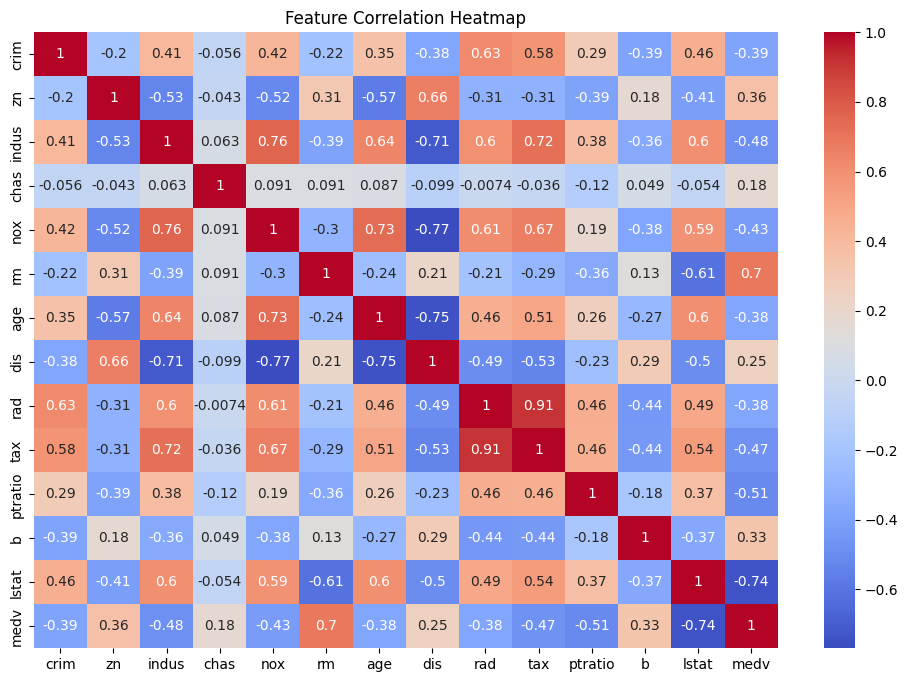


Model Performance:
RMSE: 4.928602182665336
R2 Score: 0.668759493535632


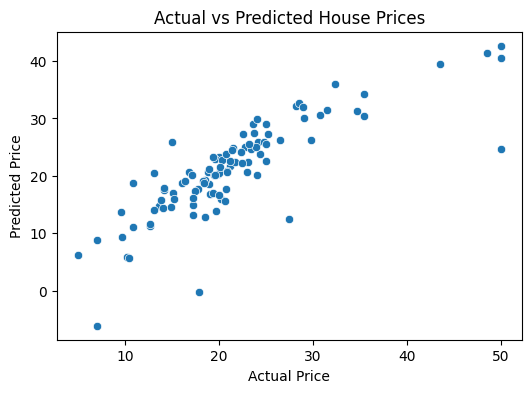


Model saved as house_price_model.pkl


In [2]:
# House Price Prediction using Linear Regression

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score

import joblib

# -----------------------------
# Load Dataset
# -----------------------------
df = pd.read_csv("https://raw.githubusercontent.com/selva86/datasets/master/BostonHousing.csv")

print("Data Preview:")
print(df.head())

# -----------------------------
# Correlation Heatmap
# -----------------------------
plt.figure(figsize=(12,8))
sns.heatmap(df.corr(), annot=True, cmap="coolwarm")
plt.title("Feature Correlation Heatmap")
plt.show()

# -----------------------------
# Train-Test Split
# -----------------------------
X = df.drop("medv", axis=1)   # Features
y = df["medv"]                # Target (house price)

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# -----------------------------
# Feature Scaling
# -----------------------------
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# -----------------------------
# Train Model
# -----------------------------
model = LinearRegression()

model.fit(X_train_scaled, y_train)

# -----------------------------
# Predictions
# -----------------------------
y_pred = model.predict(X_test_scaled)

# -----------------------------
# Model Evaluation
# -----------------------------
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
r2 = r2_score(y_test, y_pred)

print("\nModel Performance:")
print("RMSE:", rmse)
print("R2 Score:", r2)

# -----------------------------
# Actual vs Predicted Plot
# -----------------------------
plt.figure(figsize=(6,4))
sns.scatterplot(x=y_test, y=y_pred)

plt.xlabel("Actual Price")
plt.ylabel("Predicted Price")
plt.title("Actual vs Predicted House Prices")

plt.show()

# -----------------------------
# Save Model
# -----------------------------
joblib.dump(model, "house_price_model.pkl")

print("\nModel saved as house_price_model.pkl")